# COMP9517 Group Project — Deep Learning Experiments

This notebook covers the section you are responsible for:

1. Compare different deep neural network architectures;
2. Compare different data augmentation strategies;
3. Compare training from random initialization (from scratch) with transfer learning using ImageNet pretrained weights;
4. Record training curves, runtime, and final test metrics;
5. Produce confusion analysis and failure cases for use in the report.

Recommended core experiments:

| Experiment | Architecture | Initialization | Data Augmentation | Comparison Objective |
|---|---|---|---|---|
| E1 | ResNet-18 | Random | Basic | Scratch baseline |
| E2 | ResNet-18 | ImageNet | Basic | Transfer learning vs Scratch |
| E3 | ResNet-18 | ImageNet | Strong | Basic vs Strong augmentation |
| E4 | EfficientNet-B0 | ImageNet | Strong | Different network architecture |

This changes only one design choice at a time where possible, providing a clear ablation study.

## 0. Recommended Execution Order

1. Select a GPU in Colab;
2. Mount Drive and extract the dataset;
3. Check the data structure and sample counts;
4. First run the complete pipeline with `RUN_MODE = "smoke"`;
5. Then change it to `RUN_MODE = "full"`;
6. Run the four full experiments one at a time;
7. Summarize the results and perform error analysis.

Do not repeatedly tune hyperparameters based on test-set results. Use only the training and validation sets during training, and reserve the test set for final evaluation.

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Warning: In Colab, select Runtime -> Change runtime type -> GPU.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile
from pathlib import Path

ZIP_PATH = Path("/content/drive/MyDrive/COMP9517/shared_dataset_seed9517.zip")
EXTRACT_DIR = Path("/content/dataset")

if not ZIP_PATH.is_file():
    raise FileNotFoundError(
        f"Archive not found: {ZIP_PATH}\n"
        "Please check the shared-folder shortcut and file path."
    )

print(f"Archive found: {ZIP_PATH}")
print(f"Size: {ZIP_PATH.stat().st_size / 1024**3:.2f} GB")

marker = EXTRACT_DIR / ".extract_complete"
if not marker.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    marker.write_text("complete", encoding="utf-8")
    print("Extraction complete.")
else:
    print("Already extracted in this session; skipping.")

print("\nTop-level directories:")
for item in sorted(EXTRACT_DIR.iterdir()):
    print("-", item)

Mounted at /content/drive
Archive found: /content/drive/MyDrive/COMP9517/shared_dataset_seed9517.zip
Size: 2.52 GB
Extracting...
Extraction complete.

Top-level directories:
- /content/dataset/.extract_complete
- /content/dataset/shared_dataset_seed9517


## 1. Imports and Global Configuration

`smoke` samples only a small subset and trains for 2 epochs to verify the code.

`full` runs the full experiment. Models, training history, and metrics are saved to Google Drive.

In [ ]:
import os, json, time, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

SEED = 42
RUN_MODE = "full"       # Change to "full" for full training
IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2
SCRATCH_EPOCHS = 25
TRANSFER_EPOCHS = 12
PATIENCE = 5

OUTPUT_DIR = Path("/content/drive/MyDrive/COMP9517/deep_learning_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Run mode:", RUN_MODE)
print("Output directory:", OUTPUT_DIR)

Device: cuda
Run mode: full
Output directory: /content/drive/MyDrive/COMP9517/deep_learning_results


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

## 2. Automatically Locate train / val / test

The archive is assumed to use the PyTorch `ImageFolder` structure:

```text
dataset_root/
├── train/class001/...
├── val/class001/...
└── test/class001/...
```

The code below recursively searches for the root directory containing these three splits.

In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def looks_like_split(path):
    path = Path(path)
    if not path.is_dir():
        return False
    class_dirs = [p for p in path.iterdir() if p.is_dir()]
    if not class_dirs:
        return False
    for class_dir in class_dirs[:10]:
        if any(f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS for f in class_dir.iterdir()):
            return True
    return False

def find_split_dirs(search_root):
    candidates = []
    for root, dirs, _ in os.walk(search_root):
        root_path = Path(root)
        lower = {d.lower(): root_path / d for d in dirs}
        train_dir = lower.get("train")
        val_dir = lower.get("val") or lower.get("valid") or lower.get("validation")
        test_dir = lower.get("test")
        if train_dir and val_dir and test_dir:
            if all(looks_like_split(p) for p in (train_dir, val_dir, test_dir)):
                candidates.append((root_path, train_dir, val_dir, test_dir))
    if not candidates:
        raise FileNotFoundError("Could not automatically locate train/val/test. Run the next cell to inspect the directory structure.")
    candidates.sort(key=lambda x: len(x[0].parts))
    return candidates[0]

DATASET_ROOT, TRAIN_DIR, VAL_DIR, TEST_DIR = find_split_dirs(EXTRACT_DIR)
print("Dataset root:", DATASET_ROOT)
print("Train:", TRAIN_DIR)
print("Val:  ", VAL_DIR)
print("Test: ", TEST_DIR)

Dataset root: /content/dataset/shared_dataset_seed9517/images
Train: /content/dataset/shared_dataset_seed9517/images/train
Val:   /content/dataset/shared_dataset_seed9517/images/validation
Test:  /content/dataset/shared_dataset_seed9517/images/test


In [ ]:
def print_directory_tree(root, max_depth=3, max_items=15):
    root = Path(root)
    print(root)
    for current_root, dirs, files in os.walk(root):
        current = Path(current_root)
        depth = len(current.relative_to(root).parts)
        if depth >= max_depth:
            dirs[:] = []
            continue
        indent = "    " * depth
        for d in sorted(dirs)[:max_items]:
            print(f"{indent}├── {d}/")
        image_files = [f for f in files if Path(f).suffix.lower() in IMAGE_EXTENSIONS]
        if image_files:
            print(f"{indent}└── [images: {len(image_files)}]")

# Uncomment if automatic detection fails:
# print_directory_tree(EXTRACT_DIR)

## 3. Data Augmentation

- The validation and test sets use only deterministic preprocessing, with no random augmentation;
- `basic`: random crop and horizontal flip;
- `strong`: additionally applies rotation, affine transforms, color jitter, and random erasing;
- When comparing augmentation strategies, keep all other settings fixed.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def build_transforms(augmentation="basic"):
    if augmentation == "basic":
        train_transform = transforms.Compose([
            transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
            transforms.RandomHorizontalFlip(0.5),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    elif augmentation == "strong":
        train_transform = transforms.Compose([
            transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.60, 1.0)),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomRotation(15),
            transforms.RandomAffine(0, translate=(0.08, 0.08), scale=(0.90, 1.10)),
            transforms.ColorJitter(0.25, 0.25, 0.25, 0.05),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
        ])
    else:
        raise ValueError("augmentation must be either basic or strong")

    eval_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return train_transform, eval_transform

## 4. Dataset and DataLoader

`ImageFolder` automatically maps class folder names to integer labels. The code strictly verifies that the class mappings for train, val, and test are identical.

In [ ]:
def build_dataloaders(augmentation, batch_size=BATCH_SIZE, run_mode=RUN_MODE):
    train_tf, eval_tf = build_transforms(augmentation)
    train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
    val_ds = datasets.ImageFolder(VAL_DIR, transform=eval_tf)
    test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_tf)

    if train_ds.class_to_idx != val_ds.class_to_idx:
        raise ValueError("The train and val class mappings do not match")
    if train_ds.class_to_idx != test_ds.class_to_idx:
        raise ValueError("The train and test class mappings do not match")

    if run_mode == "smoke":
        rng = np.random.default_rng(SEED)
        def subset(ds, n):
            n = min(n, len(ds))
            idx = rng.choice(len(ds), size=n, replace=False).tolist()
            return Subset(ds, idx)
        train_use, val_use, test_use = subset(train_ds, 1024), subset(val_ds, 512), subset(test_ds, 512)
    else:
        train_use, val_use, test_use = train_ds, val_ds, test_ds

    args = dict(batch_size=batch_size, num_workers=NUM_WORKERS,
                pin_memory=torch.cuda.is_available(), persistent_workers=NUM_WORKERS > 0)
    return {
        "train_dataset_full": train_ds,
        "val_dataset_full": val_ds,
        "test_dataset_full": test_ds,
        "train_loader": DataLoader(train_use, shuffle=True, **args),
        "val_loader": DataLoader(val_use, shuffle=False, **args),
        "test_loader": DataLoader(test_use, shuffle=False, **args),
        "classes": train_ds.classes,
        "num_classes": len(train_ds.classes),
    }

data_check = build_dataloaders("basic")
print("Classes:", data_check["num_classes"])
print("Train images:", len(data_check["train_dataset_full"]))
print("Val images:  ", len(data_check["val_dataset_full"]))
print("Test images: ", len(data_check["test_dataset_full"]))
print("First classes:", data_check["classes"][:10])

Classes: 500
Train images: 20000
Val images:   5000
Test images:  5000
First classes: ['000', '001', '002', '003', '004', '005', '006', '007', '008', '009']


In [ ]:
def class_counts(ds):
    return Counter(target for _, target in ds.samples)

for name, ds in [("train", data_check["train_dataset_full"]),
                 ("val", data_check["val_dataset_full"]),
                 ("test", data_check["test_dataset_full"])]:
    values = list(class_counts(ds).values())
    print(f"{name}: classes={len(values)}, min={min(values)}, max={max(values)}, mean={np.mean(values):.2f}, total={sum(values)}")

train: classes=500, min=40, max=40, mean=40.00, total=20000
val: classes=500, min=10, max=10, mean=10.00, total=5000
test: classes=500, min=10, max=10, mean=10.00, total=5000


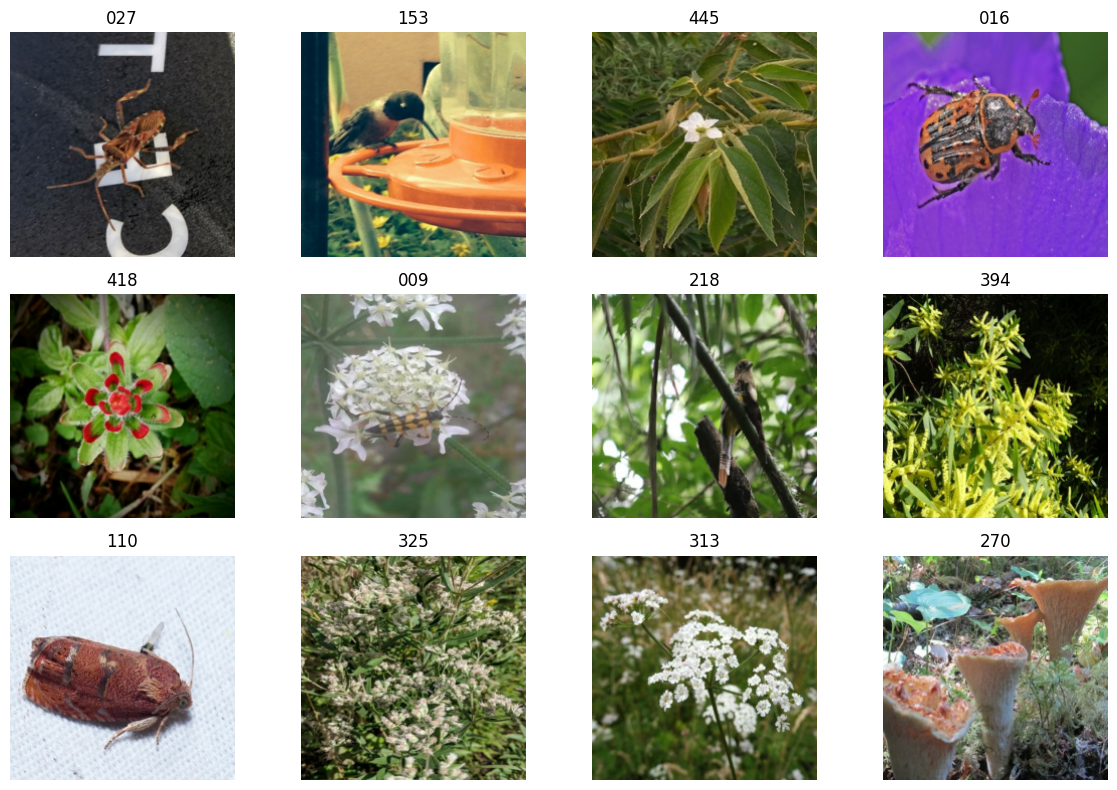

In [ ]:
def denormalize(x):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(x.cpu() * std + mean, 0, 1)

images, labels = next(iter(data_check["train_loader"]))
plt.figure(figsize=(12, 8))
for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(denormalize(images[i]).permute(1, 2, 0))
    plt.title(data_check["classes"][labels[i].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Create the Model

- `resnet18`: a classic, reliable architecture used as the main baseline;
- `efficientnet_b0`: a parameter-efficient architecture;
- `mobilenet_v3_small`: an optional lightweight model.

`pretrained=False` uses random initialization; `pretrained=True` loads ImageNet weights.

In [ ]:
def create_model(architecture, num_classes, pretrained):
    if architecture == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif architecture == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif architecture == "mobilenet_v3_small":
        weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    else:
        raise ValueError("Unknown architecture")
    return model

def count_parameters(model):
    return sum(p.numel() for p in model.parameters()), sum(p.numel() for p in model.parameters() if p.requires_grad)

example = create_model("resnet18", data_check["num_classes"], True)
print("Parameters:", f"{count_parameters(example)[0]:,}")
del example
if torch.cuda.is_available(): torch.cuda.empty_cache()

Parameters: 11,433,012


## 6. Training and Validation

For each epoch, record train/validation loss, accuracy, macro-F1, and runtime. Save the best checkpoint based on validation macro-F1 and use early stopping.

In [ ]:
def run_one_epoch(model, loader, criterion, optimizer=None, scaler=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = total_correct = total_n = 0
    ys, preds = [], []

    for images, targets in loader:
        images, targets = images.to(DEVICE, non_blocking=True), targets.to(DEVICE, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=torch.cuda.is_available()):
                logits = model(images)
                loss = criterion(logits, targets)
            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
        pred = logits.argmax(1)
        n = images.size(0)
        total_loss += loss.item() * n
        total_correct += (pred == targets).sum().item()
        total_n += n
        ys.extend(targets.cpu().tolist())
        preds.extend(pred.cpu().tolist())

    _, _, macro_f1, _ = precision_recall_fscore_support(ys, preds, average="macro", zero_division=0)
    return {"loss": total_loss / total_n, "accuracy": total_correct / total_n, "macro_f1": macro_f1}

In [ ]:
def train_model(model, train_loader, val_loader, name, epochs, learning_rate, weight_decay=1e-4, patience=PATIENCE):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.3, patience=2, min_lr=1e-6)
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

    history, best_f1, no_improve = [], -1.0, 0
    checkpoint_path = OUTPUT_DIR / f"{name}_best.pt"

    for epoch in range(1, epochs + 1):
        start = time.perf_counter()
        tr = run_one_epoch(model, train_loader, criterion, optimizer, scaler)
        va = run_one_epoch(model, val_loader, criterion)
        scheduler.step(va["loss"])
        row = {
            "epoch": epoch, "learning_rate": optimizer.param_groups[0]["lr"],
            "train_loss": tr["loss"], "train_accuracy": tr["accuracy"], "train_macro_f1": tr["macro_f1"],
            "val_loss": va["loss"], "val_accuracy": va["accuracy"], "val_macro_f1": va["macro_f1"],
            "epoch_seconds": time.perf_counter() - start,
        }
        history.append(row)
        print(f"Epoch {epoch:02d}/{epochs} | train loss {tr['loss']:.4f} acc {tr['accuracy']:.4f} | val loss {va['loss']:.4f} acc {va['accuracy']:.4f} F1 {va['macro_f1']:.4f} | {row['epoch_seconds']:.1f}s")

        if va["macro_f1"] > best_f1:
            best_f1, no_improve = va["macro_f1"], 0
            torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(), "best_val_macro_f1": best_f1}, checkpoint_path)
            print("  Saved best checkpoint")
        else:
            no_improve += 1

        pd.DataFrame(history).to_csv(OUTPUT_DIR / f"{name}_history.csv", index=False)
        if no_improve >= patience:
            print("Early stopping")
            break

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    return model, pd.DataFrame(history), checkpoint_path

In [ ]:
def plot_history(df, name):
    plt.figure(figsize=(8,5))
    plt.plot(df.epoch, df.train_loss, label="Train")
    plt.plot(df.epoch, df.val_loss, label="Validation")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(name + ": loss"); plt.legend(); plt.grid(alpha=.3); plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(df.epoch, df.train_accuracy, label="Train")
    plt.plot(df.epoch, df.val_accuracy, label="Validation")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title(name + ": accuracy"); plt.legend(); plt.grid(alpha=.3); plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(df.epoch, df.val_macro_f1, label="Validation macro-F1")
    plt.xlabel("Epoch"); plt.ylabel("Macro-F1"); plt.title(name + ": macro-F1"); plt.legend(); plt.grid(alpha=.3); plt.show()

## 7. Final Test Metrics

Report top-1, top-5, macro precision, macro recall, macro-F1, and inference time.

In [ ]:
@torch.no_grad()
def evaluate_model(model, loader, class_names):
    model.eval().to(DEVICE)
    ys, preds, top5s = [], [], []
    top1_correct = top5_correct = total = 0
    start = time.perf_counter()

    for images, targets in loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=torch.cuda.is_available()):
            logits = model(images)
        pred = logits.argmax(1)
        top5 = logits.topk(min(5, logits.size(1)), dim=1).indices
        top1_correct += (pred == targets).sum().item()
        top5_correct += top5.eq(targets.view(-1,1)).any(1).sum().item()
        total += images.size(0)
        ys.extend(targets.cpu().tolist()); preds.extend(pred.cpu().tolist()); top5s.extend(top5.cpu().tolist())

    elapsed = time.perf_counter() - start
    p, r, f1, _ = precision_recall_fscore_support(ys, preds, average="macro", zero_division=0)
    return {
        "metrics": {"top1_accuracy": top1_correct/total, "top5_accuracy": top5_correct/total,
                    "macro_precision": p, "macro_recall": r, "macro_f1": f1,
                    "inference_seconds": elapsed, "images_per_second": total/elapsed, "num_test_images": total},
        "targets": np.array(ys), "predictions": np.array(preds), "top5_predictions": np.array(top5s),
        "class_names": class_names,
    }

## 8. Experiment Runner

Automatically builds the model, trains it, plots curves, evaluates on the test set, and saves JSON/CSV files.

In [ ]:
def run_experiment(config):
    set_seed(SEED)
    name = config["name"]
    print("="*80, "\n", name, "\n", json.dumps(config, indent=2), "\n", "="*80)
    data = build_dataloaders(config["augmentation"], config.get("batch_size", BATCH_SIZE), RUN_MODE)
    model = create_model(config["architecture"], data["num_classes"], config["pretrained"])
    total_params, trainable_params = count_parameters(model)
    epochs = 2 if RUN_MODE == "smoke" else config["epochs"]

    start = time.perf_counter()
    model, history, checkpoint = train_model(model, data["train_loader"], data["val_loader"], name,
                                             epochs, config["learning_rate"], config.get("weight_decay",1e-4),
                                             config.get("patience",PATIENCE))
    training_seconds = time.perf_counter() - start
    plot_history(history, name)
    evaluation = evaluate_model(model, data["test_loader"], data["classes"])
    metrics = evaluation["metrics"] | {
        "experiment_name": name, "architecture": config["architecture"], "pretrained": config["pretrained"],
        "augmentation": config["augmentation"], "epochs_completed": len(history),
        "best_val_macro_f1": float(history.val_macro_f1.max()), "training_seconds": training_seconds,
        "total_parameters": total_params, "trainable_parameters": trainable_params,
        "run_mode": RUN_MODE, "seed": SEED,
    }
    print(json.dumps(metrics, indent=2))

    (OUTPUT_DIR / f"{name}_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    pd.DataFrame({"target": evaluation["targets"], "prediction": evaluation["predictions"],
                  "target_name": [data["classes"][i] for i in evaluation["targets"]],
                  "prediction_name": [data["classes"][i] for i in evaluation["predictions"]]}).to_csv(
                      OUTPUT_DIR / f"{name}_predictions.csv", index=False)
    saved_config = config | {"seed":SEED, "image_size":IMAGE_SIZE, "num_classes":data["num_classes"],
                             "train_images":len(data["train_dataset_full"]), "val_images":len(data["val_dataset_full"]),
                             "test_images":len(data["test_dataset_full"]), "checkpoint":str(checkpoint)}
    (OUTPUT_DIR / f"{name}_config.json").write_text(json.dumps(saved_config, indent=2), encoding="utf-8")
    return {"model":model, "history":history, "evaluation":evaluation, "metrics":metrics, "data":data}

## 9. Four Core Experiment Configurations

- E1 vs E2: changes only random initialization / ImageNet pretraining;
- E2 vs E3: changes only basic / strong augmentation;
- E3 vs E4: primarily changes the network architecture.

In [ ]:
EXPERIMENTS = {
    "E1": {"name":"E1_resnet18_scratch_basic", "architecture":"resnet18", "pretrained":False,
           "augmentation":"basic", "epochs":SCRATCH_EPOCHS, "learning_rate":1e-3, "weight_decay":1e-4, "patience":6},
    "E2": {"name":"E2_resnet18_pretrained_basic", "architecture":"resnet18", "pretrained":True,
           "augmentation":"basic", "epochs":TRANSFER_EPOCHS, "learning_rate":3e-4, "weight_decay":1e-4, "patience":4},
    "E3": {"name":"E3_resnet18_pretrained_strong", "architecture":"resnet18", "pretrained":True,
           "augmentation":"strong", "epochs":TRANSFER_EPOCHS, "learning_rate":3e-4, "weight_decay":1e-4, "patience":4},
    "E4": {"name":"E4_efficientnet_b0_pretrained_strong", "architecture":"efficientnet_b0", "pretrained":True,
           "augmentation":"strong", "epochs":TRANSFER_EPOCHS, "learning_rate":3e-4, "weight_decay":1e-4, "patience":4},
}
pd.DataFrame(EXPERIMENTS).T

,name,architecture,pretrained,augmentation,epochs,learning_rate,weight_decay,patience
E1,E1_resnet18_scratch_basic,resnet18,False,basic,25,0.001,0.0001,6
E2,E2_resnet18_pretrained_basic,resnet18,True,basic,12,0.0003,0.0001,4
E3,E3_resnet18_pretrained_strong,resnet18,True,strong,12,0.0003,0.0001,4
E4,E4_efficientnet_b0_pretrained_strong,efficientnet_b0,True,strong,12,0.0003,0.0001,4


## 10. Smoke Test

Keep `RUN_MODE = "smoke"` and run one experiment first. These results are only for checking the code and must not be used in the final report.

In [ ]:
# smoke_result = run_experiment(EXPERIMENTS["E2"])

## 11. Full Experiments

Return to the configuration cell, change `RUN_MODE` to `"full"`, and uncomment the experiments one at a time. It is recommended to finish one experiment and confirm its checkpoint was saved before running the next.

 E4_efficientnet_b0_pretrained_strong 
 {
  "name": "E4_efficientnet_b0_pretrained_strong",
  "architecture": "efficientnet_b0",
  "pretrained": true,
  "augmentation": "strong",
  "epochs": 12,
  "learning_rate": 0.0003,
  "weight_decay": 0.0001,
  "patience": 4
} 
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 179MB/s]


Epoch 01/12 | train loss 4.7662 acc 0.1919 | val loss 3.1124 acc 0.4664 F1 0.4352 | 251.3s
  Saved best checkpoint
Epoch 02/12 | train loss 2.9086 acc 0.5085 | val loss 2.4925 acc 0.6022 F1 0.5911 | 221.7s
  Saved best checkpoint
Epoch 03/12 | train loss 2.3688 acc 0.6415 | val loss 2.3109 acc 0.6412 F1 0.6311 | 222.9s
  Saved best checkpoint
Epoch 04/12 | train loss 2.0805 acc 0.7210 | val loss 2.2105 acc 0.6656 F1 0.6595 | 221.7s
  Saved best checkpoint
Epoch 05/12 | train loss 1.9056 acc 0.7647 | val loss 2.1647 acc 0.6918 F1 0.6849 | 221.2s
  Saved best checkpoint
Epoch 06/12 | train loss 1.7617 acc 0.8109 | val loss 2.1227 acc 0.7002 F1 0.6959 | 222.7s
  Saved best checkpoint
Epoch 07/12 | train loss 1.6513 acc 0.8458 | val loss 2.1109 acc 0.7066 F1 0.7006 | 218.7s
  Saved best checkpoint
Epoch 08/12 | train loss 1.5699 acc 0.8740 | val loss 2.0902 acc 0.7078 F1 0.7032 | 233.2s
  Saved best checkpoint
Epoch 09/12 | train loss 1.5008 acc 0.8912 | val loss 2.1073 acc 0.7038 F1 0.700

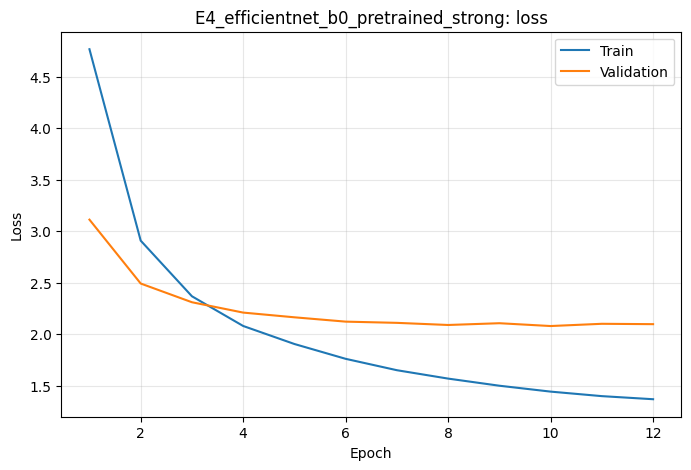

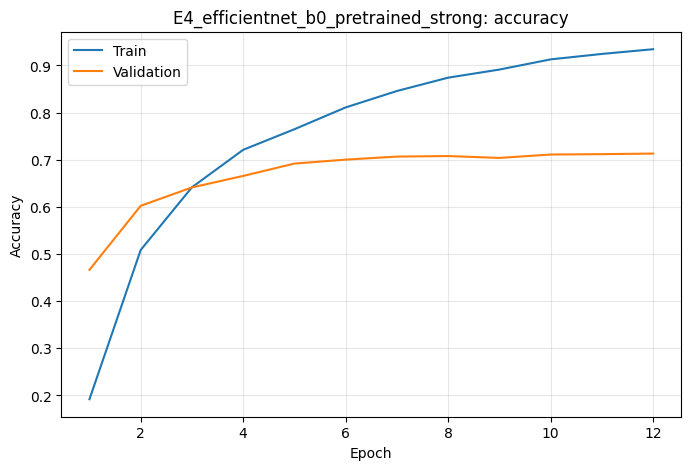

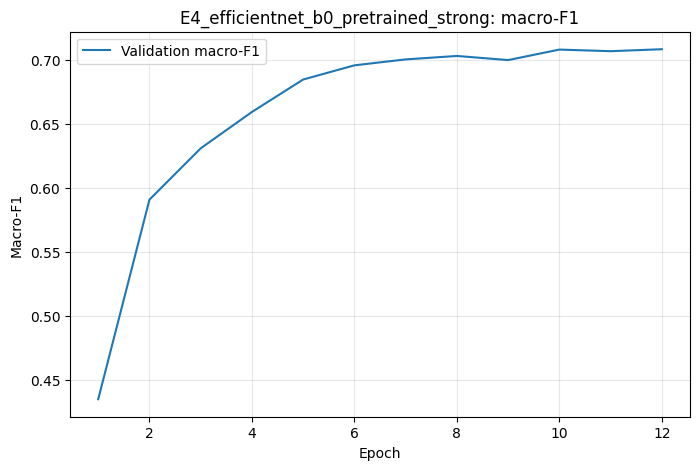

{
  "top1_accuracy": 0.7216,
  "top5_accuracy": 0.8986,
  "macro_precision": 0.7438267907960633,
  "macro_recall": 0.7216,
  "macro_f1": 0.7177035753339935,
  "inference_seconds": 29.035678951999216,
  "images_per_second": 172.20193157066615,
  "num_test_images": 5000,
  "experiment_name": "E4_efficientnet_b0_pretrained_strong",
  "architecture": "efficientnet_b0",
  "pretrained": true,
  "augmentation": "strong",
  "epochs_completed": 12,
  "best_val_macro_f1": 0.7085023502568357,
  "training_seconds": 2817.28202393,
  "total_parameters": 4648048,
  "trainable_parameters": 4648048,
  "run_mode": "full",
  "seed": 42
}


In [ ]:
# result_E1 = run_experiment(EXPERIMENTS["E1"])
# result_E2 = run_experiment(EXPERIMENTS["E2"])
# result_E3 = run_experiment(EXPERIMENTS["E3"])
result_E4 = run_experiment(EXPERIMENTS["E4"])

## 12. Summarize Experiment Results

In [ ]:
def load_all_metrics(output_dir):
    rows = []
    for path in sorted(Path(output_dir).glob("*_metrics.json")):
        rows.append(json.loads(path.read_text(encoding="utf-8")))
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("macro_f1", ascending=False)

summary_df = load_all_metrics(OUTPUT_DIR)
display(summary_df)
if not summary_df.empty:
    summary_df.to_csv(OUTPUT_DIR / "experiment_summary.csv", index=False)

,top1_accuracy,top5_accuracy,macro_precision,macro_recall,macro_f1,inference_seconds,images_per_second,num_test_images,experiment_name,architecture,pretrained,augmentation,epochs_completed,best_val_macro_f1,training_seconds,total_parameters,trainable_parameters,run_mode,seed
3,0.7216,0.8986,0.743827,0.7216,0.717704,29.035679,172.201932,5000,E4_efficientnet_b0_pretrained_strong,efficientnet_b0,True,strong,12,0.708502,2817.282024,4648048,4648048,full,42
1,0.5772,0.8038,0.623387,0.5772,0.571738,24.279186,205.937710,5000,E2_resnet18_pretrained_basic,resnet18,True,basic,12,0.570504,1593.570680,11433012,11433012,full,42
2,0.5636,0.7974,0.613206,0.5636,0.554160,25.202335,198.394313,5000,E3_resnet18_pretrained_strong,resnet18,True,strong,12,0.545855,2621.508600,11433012,11433012,full,42
0,0.3208,0.5632,0.342171,0.3208,0.316167,28.514908,175.346876,5000,E1_resnet18_scratch_basic,resnet18,False,basic,25,0.315383,3628.684587,11433012,11433012,full,42


## 13. Most Frequently Confused Class Pairs

A full 500×500 confusion matrix is too dense. Instead, identify the most common error directions and plot a local matrix for 10–20 related classes.

In [ ]:
# def most_confused_pairs(targets, predictions, class_names, top_n=20):
#     pairs = Counter((t,p) for t,p in zip(targets,predictions) if t != p)
#     return pd.DataFrame([
#         {"true_id":t, "true_class":class_names[t], "predicted_id":p,
#          "predicted_class":class_names[p], "count":n}
#         for (t,p),n in pairs.most_common(top_n)
#     ])

# confused_pairs_df = most_confused_pairs(
#     smoke_result["evaluation"]["targets"], smoke_result["evaluation"]["predictions"],
#     smoke_result["evaluation"]["class_names"], 20)
# confused_pairs_df

In [ ]:
def plot_selected_confusion(targets, predictions, class_names, selected_ids):
    mask = np.isin(targets, selected_ids) & np.isin(predictions, selected_ids)
    cm = confusion_matrix(targets[mask], predictions[mask], labels=selected_ids)
    labels = [class_names[i] for i in selected_ids]
    plt.figure(figsize=(10,8)); plt.imshow(cm); plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=90); plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Selected-class confusion matrix")
    plt.tight_layout(); plt.show()

# Example after completing the full experiments:
# ids = sorted(set(confused_pairs_df.true_id.head(10)) | set(confused_pairs_df.predicted_id.head(10)))
# plot_selected_confusion(result_E4["evaluation"]["targets"], result_E4["evaluation"]["predictions"],
#                         result_E4["evaluation"]["class_names"], ids)

## 14. Inspect Misclassified Images

In [ ]:
@torch.no_grad()
def collect_errors(model, dataset, max_examples=16):
    model.eval().to(DEVICE)
    errors=[]
    for i in range(len(dataset)):
        image,target = dataset[i]
        pred = model(image.unsqueeze(0).to(DEVICE)).argmax(1).item()
        if pred != target:
            errors.append((image,target,pred))
        if len(errors) >= max_examples:
            break
    return errors

def show_errors(errors, class_names):
    rows = int(np.ceil(len(errors)/4))
    plt.figure(figsize=(16,4*rows))
    for i,(image,target,pred) in enumerate(errors):
        plt.subplot(rows,4,i+1); plt.imshow(denormalize(image).permute(1,2,0))
        plt.title(f"True: {class_names[target]}\nPred: {class_names[pred]}"); plt.axis("off")
    plt.tight_layout(); plt.show()

# errors = collect_errors(result_E4["model"], result_E4["data"]["test_dataset_full"])
# show_errors(errors, result_E4["data"]["classes"])

## 15. Result Interpretation Framework

### E1 vs E2: Transfer Learning

Compare convergence speed, best validation macro-F1, test top-1/top-5/macro-F1, and training time. With limited data, pretrained models are generally faster and more stable.

### E2 vs E3: Data Augmentation

Examine whether strong augmentation reduces training accuracy while improving validation/test performance and whether it narrows the train–val gap. Also discuss how excessive color jitter may harm fine-grained recognition.

### E3 vs E4: Architecture

Compare accuracy, macro-F1, parameter count, training time, and inference speed rather than relying on accuracy alone.

## 16. Required Items for the Report

- Random seed and class list;
- Numbers of train/val/test images;
- Input size and augmentation;
- Network and whether it is pretrained;
- optimizer、learning rate、weight decay、batch size、epoch；
- Checkpoint selection criterion and early stopping;
- top-1、top-5、macro precision/recall/F1；
- Training and testing time;
- Loss/accuracy curves;
- Most confused class pairs and representative misclassified images.

Before full training, confirm that there are at least 500 classes, the three splits are strictly separated, and the test set is not used for tuning.